In [1]:
import cleanup
import plotting
%load_ext autoreload
%autoreload 2

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\cleanup.py:13: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
import tkinter
from tkinter import filedialog
import scipy as scp
import scipy.stats as scpst

pd.options.mode.use_inf_as_na = True

C:\Users\hpnhp\AppData\Local\Temp\ipykernel_1684\2693178358.py:13: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [3]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df = cleanup.data_to_dataframe(filepath)

In [4]:
primary_df = primary_df[primary_df['Frame']<600]
primary_df = cleanup.calculate_distance_from_fixed_point(primary_df)
primary_df = cleanup.categorize_values(primary_df, 'X', 14, 1.5)

In [5]:
primary_df_interp = cleanup.interpolate_missing_values(primary_df)
primary_df_interp = cleanup.calculate_distance_from_fixed_point(primary_df_interp)

In [26]:
df_neighbour = cleanup.create_combined_real_simulated_df(df = primary_df_interp)

In [27]:
# for cond in primary_df_interp['Condition'].unique():
#     plotting.plot_trajectory_heatmaps(primary_df_interp, cond, frame_bin_size=100, grid_size=1)

In [6]:
#Defining subdataframes for analysis

df_EA = primary_df_interp[primary_df_interp['Odour'] == 'EA']
df_1P = primary_df_interp[primary_df_interp['Odour'] == '1P']
df_PA = primary_df_interp[primary_df_interp['Odour'] == 'PA']

df_crosses = primary_df_interp[(primary_df_interp['Genotype'] == 'TrhxKir') 
                              | (primary_df_interp['Genotype'] == 'CSDxKir')
                              | (primary_df_interp['Genotype'] == 'WTxCSD')
                              | (primary_df_interp['Genotype'] == 'WTxKir')
                              | (primary_df_interp['Genotype'] == 'WTxTrh')]

In [7]:
df_crosses_trh = primary_df_interp[(primary_df_interp['Genotype'] == 'TrhxKir') 
                              
                              
                              | (primary_df_interp['Genotype'] == 'WTxKir')
                              | (primary_df_interp['Genotype'] == 'WTxTrh')]

In [8]:
df_crosses_csd = primary_df_interp[
                              (primary_df_interp['Genotype'] == 'CSDxKir')
                              | (primary_df_interp['Genotype'] == 'WTxCSD')
                              
                              | (primary_df_interp['Genotype'] == 'WTxTrh')]

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:663: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_avg, x='Bin', y=distance_column, hue=condition_column,
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:663: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_avg, x='Bin', y=distance_column, hue=condition_column,


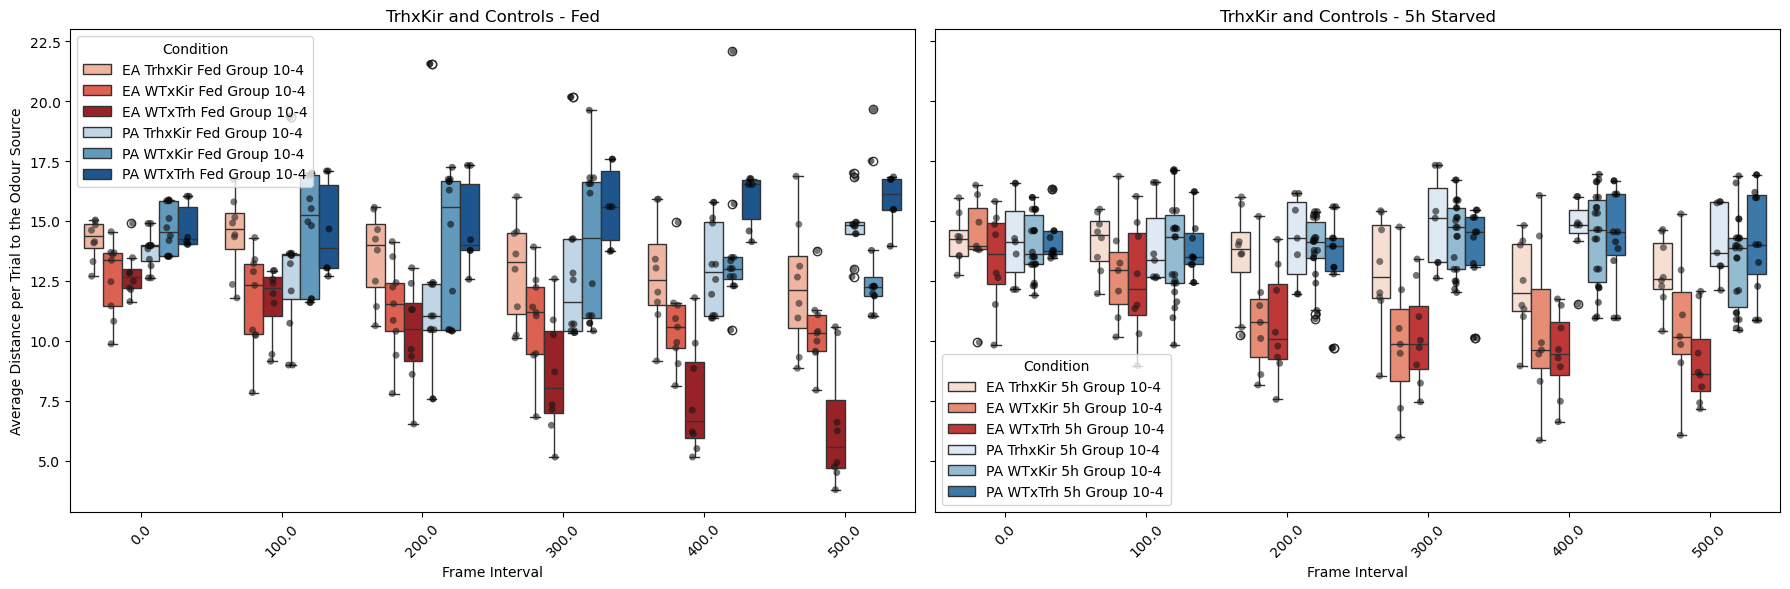

In [31]:
plotting.plot_two_distance_by_condition_averages(df_crosses_trh[df_crosses_trh['Starvation'] == 'Fed'],
                                                  df_crosses_trh[df_crosses_trh['Starvation'] == '5h'],
                                                    titles=('TrhxKir and Controls - Fed', 
                                                            'TrhxKir and Controls - 5h Starved'))

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:663: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_avg, x='Bin', y=distance_column, hue=condition_column,
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:663: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_avg, x='Bin', y=distance_column, hue=condition_column,


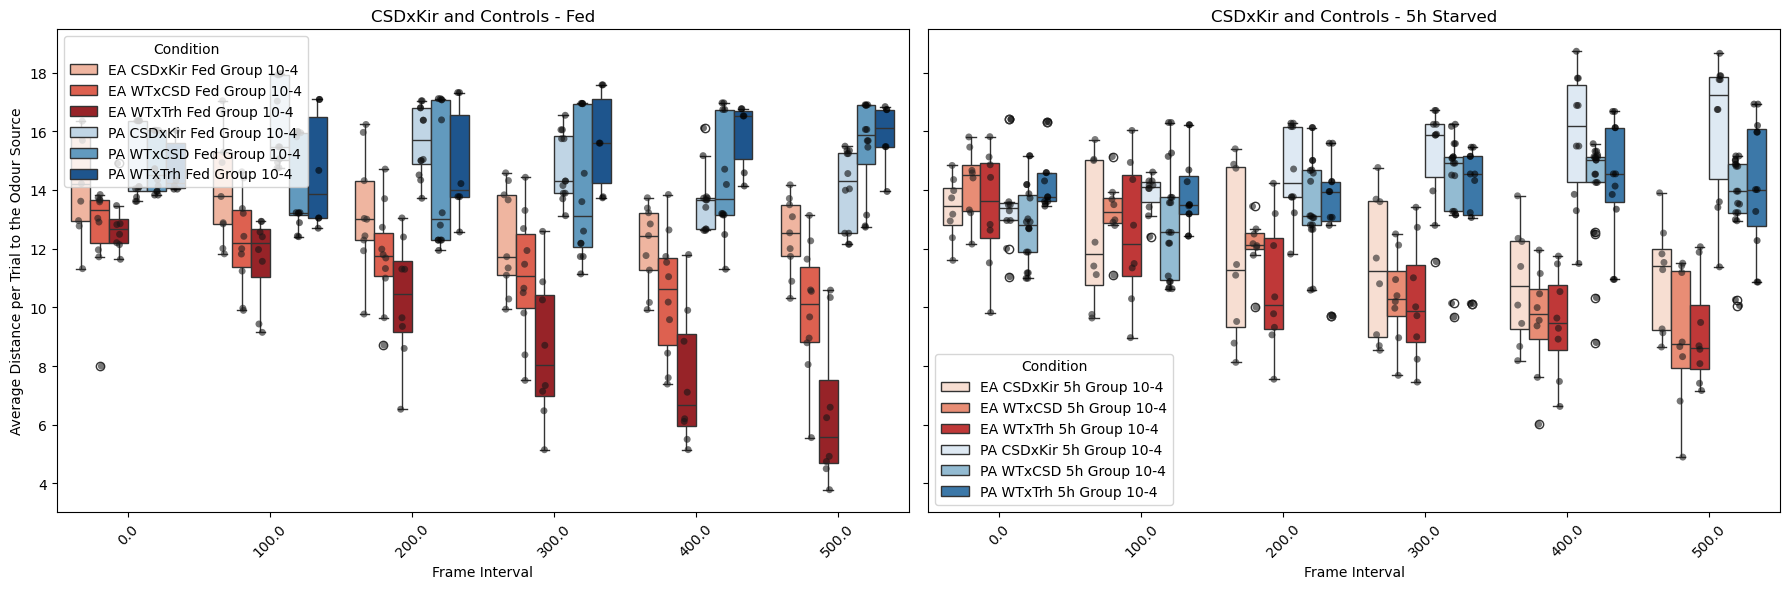

In [32]:
plotting.plot_two_distance_by_condition_averages(df_crosses_csd[df_crosses_csd['Starvation'] == 'Fed'],
                                                  df_crosses_csd[df_crosses_csd['Starvation'] == '5h'],
                                                    titles=('CSDxKir and Controls - Fed', 
                                                            'CSDxKir and Controls - 5h Starved'))

In [33]:
df_1P = primary_df_interp[primary_df_interp['Odour'] == '1P']

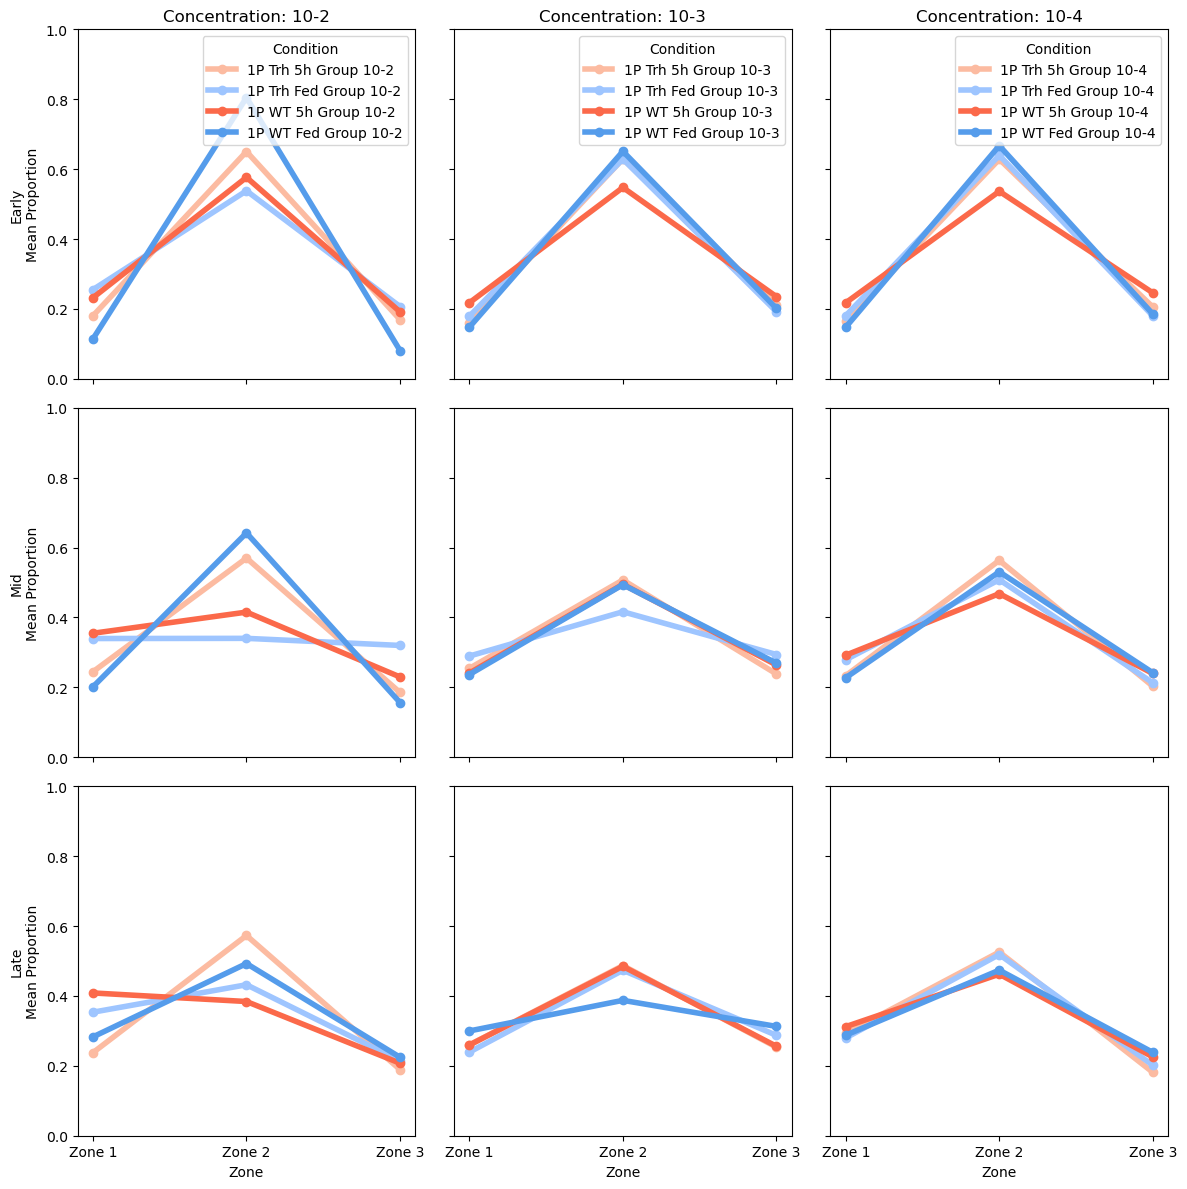

In [34]:
plotting.plot_zone_means_subplot(df_1P)       

In [35]:
avg_dist_df = df_neighbour.groupby(['Condition', 'GroupType'])['AvgNeighborDist'].mean().reset_index()

In [36]:
# Simulated: aggregate by SimGroupID and Condition
sim_summary = (
    df_neighbour[df_neighbour['GroupType'] == 'Simulated']
    .groupby(['Condition', 'SimGroupID'])['AvgNeighborDist']
    .mean()
    .reset_index()
)
sim_summary['GroupType'] = 'Simulated'

# Real: aggregate by Trial and Condition
real_summary = (
    df_neighbour[df_neighbour['GroupType'] == 'Real']
    .groupby(['Condition', 'Trial'])['AvgNeighborDist']
    .mean()
    .reset_index()
)
real_summary['GroupType'] = 'Real'
real_summary.rename(columns={'Trial': 'GroupID'}, inplace=True)

# Match column names
sim_summary.rename(columns={'SimGroupID': 'GroupID'}, inplace=True)

# Combine both into a new plotting-friendly DataFrame
summary_df = pd.concat([real_summary, sim_summary], ignore_index=True)


C:\Users\hpnhp\AppData\Local\Temp\ipykernel_26228\3664485611.py:10: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sbs.stripplot(


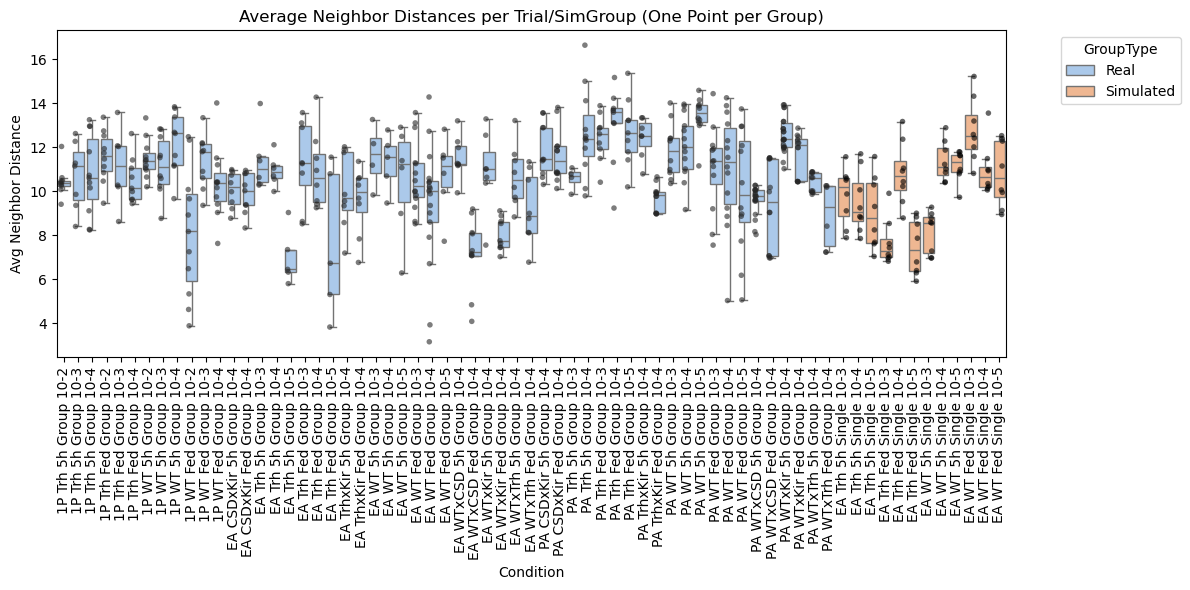

In [38]:
plt.figure(figsize=(12, 6))
sbs.boxplot(
    data=summary_df,
    x='Condition',
    y='AvgNeighborDist',
    hue='GroupType',
    palette='pastel',
    showfliers=False
)
sbs.stripplot(
    data=summary_df,
    x='Condition',
    y='AvgNeighborDist',
    hue='GroupType',
    dodge=True,
    color='black',
    size=4,
    alpha=0.6,
    legend=False
)
plt.xticks(rotation=90)
plt.ylabel('Avg Neighbor Distance')
plt.title('Average Neighbor Distances per Trial/SimGroup (One Point per Group)')
plt.legend(title='GroupType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [61]:
df_neighbour_wt = df_neighbour[(df_neighbour['Genotype'] == 'WT') 
                               & (df_neighbour['Concentration'] == '10-4')
                               & (df_neighbour['Starvation'] == 'Fed')
                               & (df_neighbour['Odour'] == 'EA')]

C:\Users\hpnhp\AppData\Local\Temp\ipykernel_26228\2588913211.py:35: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sbs.stripplot(


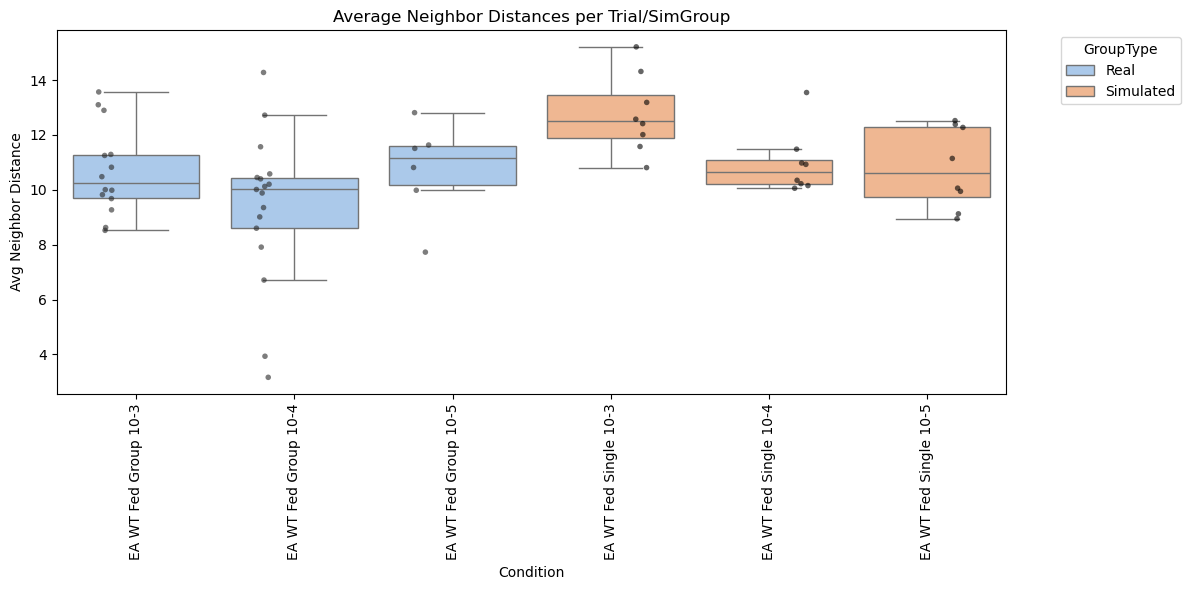

In [59]:
# Simulated: aggregate by SimGroupID and Condition
sim_summary = (
    df_neighbour_wt[df_neighbour_wt['GroupType'] == 'Simulated']
    .groupby(['Condition', 'SimGroupID'])['AvgNeighborDist']
    .mean()
    .reset_index()
)
sim_summary['GroupType'] = 'Simulated'

# Real: aggregate by Trial and Condition
real_summary = (
    df_neighbour_wt[df_neighbour_wt['GroupType'] == 'Real']
    .groupby(['Condition', 'Trial'])['AvgNeighborDist']
    .mean()
    .reset_index()
)
real_summary['GroupType'] = 'Real'
real_summary.rename(columns={'Trial': 'GroupID'}, inplace=True)

# Match column names
sim_summary.rename(columns={'SimGroupID': 'GroupID'}, inplace=True)

# Combine both into a new plotting-friendly DataFrame
summary_df = pd.concat([real_summary, sim_summary], ignore_index=True)

plt.figure(figsize=(12, 6))
sbs.boxplot(
    data=summary_df,
    x='Condition',
    y='AvgNeighborDist',
    hue='GroupType',
    palette='pastel',
    showfliers=False
)
sbs.stripplot(
    data=summary_df,
    x='Condition',
    y='AvgNeighborDist',
    hue='GroupType',
    dodge=True,
    color='black',
    size=4,
    alpha=0.6,
    legend=False
)
plt.xticks(rotation=90)
plt.ylabel('Avg Neighbor Distance')
plt.title('Average Neighbor Distances per Trial/SimGroup')
plt.legend(title='GroupType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:834: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:834: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.



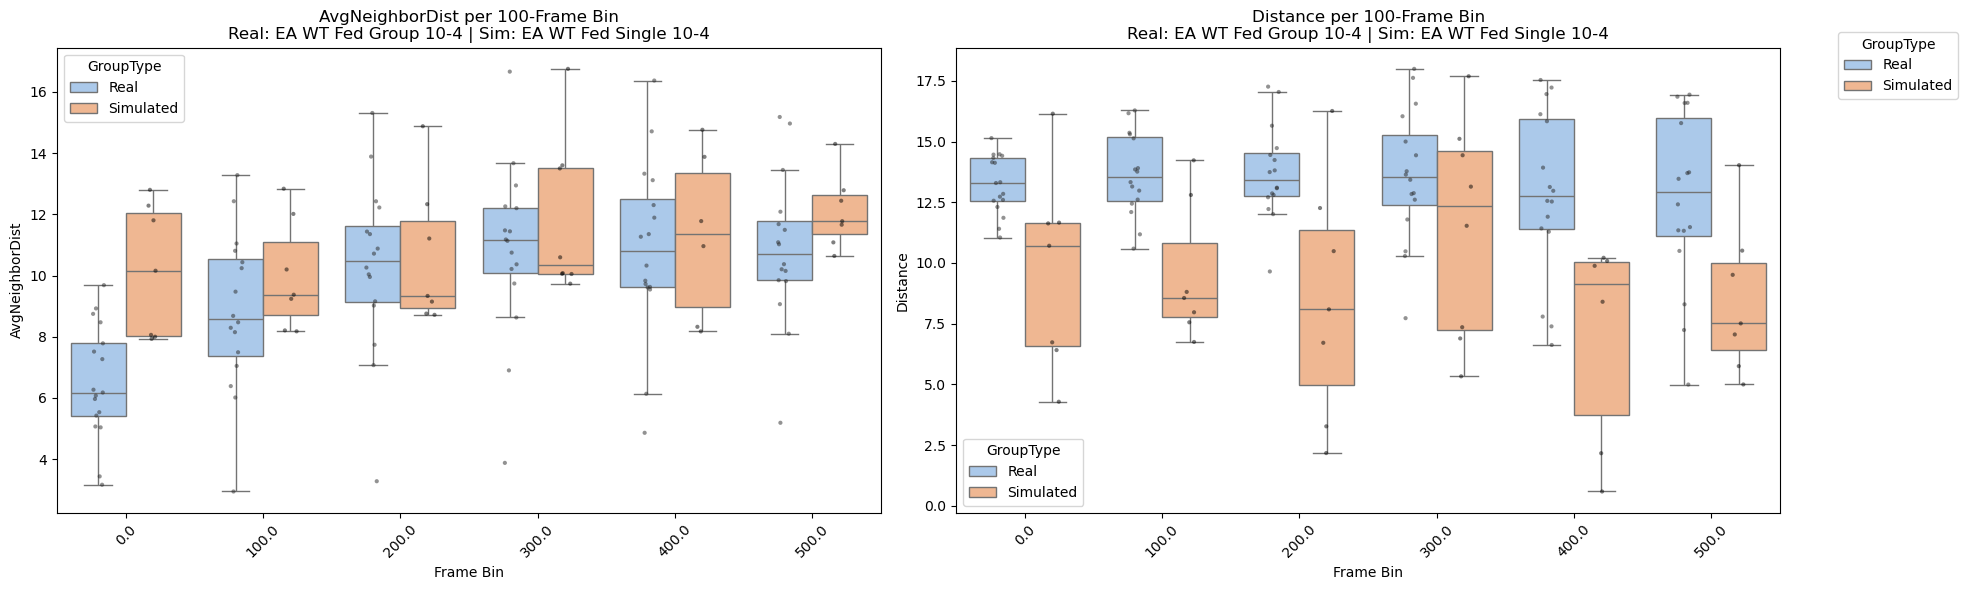

In [63]:
plotting.plot_binned_summary(df_neighbour_wt)

In [67]:
df_wt_real = primary_df_interp[(primary_df_interp['Genotype'] == 'WT') 
                               & (primary_df_interp['Concentration'] == '10-4')
                               & (primary_df_interp['Starvation'] == 'Fed')
                               & (primary_df_interp['Odour'] == 'EA')]

In [79]:
df_1P_sub = df_1P[(df_1P['Concentration'] == '10-2') & (df_1P['Genotype'] == 'WT')]
              

In [85]:
df_PA_sub = df_PA[(df_PA['Concentration'] == '10-4') & (df_PA['Genotype'] == 'Trh')]

              Condition  Frame  Proportion
0  PA Trh 5h Group 10-4    0.0    0.133333
1  PA Trh 5h Group 10-4    1.0    0.133333
2  PA Trh 5h Group 10-4    2.0    0.200000
3  PA Trh 5h Group 10-4    3.0    0.200000
4  PA Trh 5h Group 10-4    4.0    0.200000
Index(['Condition', 'Frame', 'Proportion'], dtype='object')


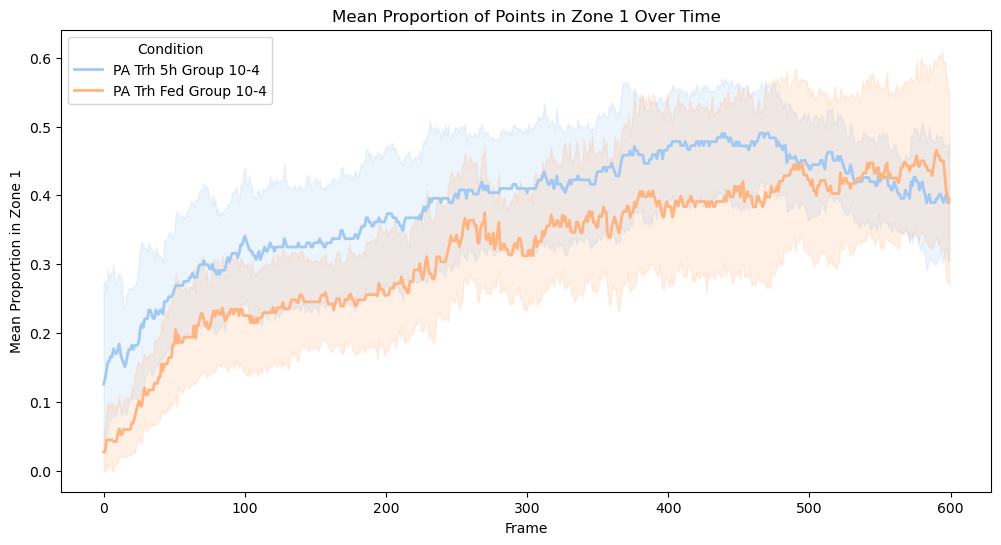

In [86]:
plotting.plot_zone_1_over_time(df_PA_sub)

In [14]:
df_EA_sub = primary_df_interp[(primary_df_interp['Concentration'] == '10-4') 
             & (primary_df_interp['Genotype'] == 'Trh')
             & (primary_df_interp['Odour'] == 'EA')
             & (primary_df_interp['Collective'] == 'Group')]

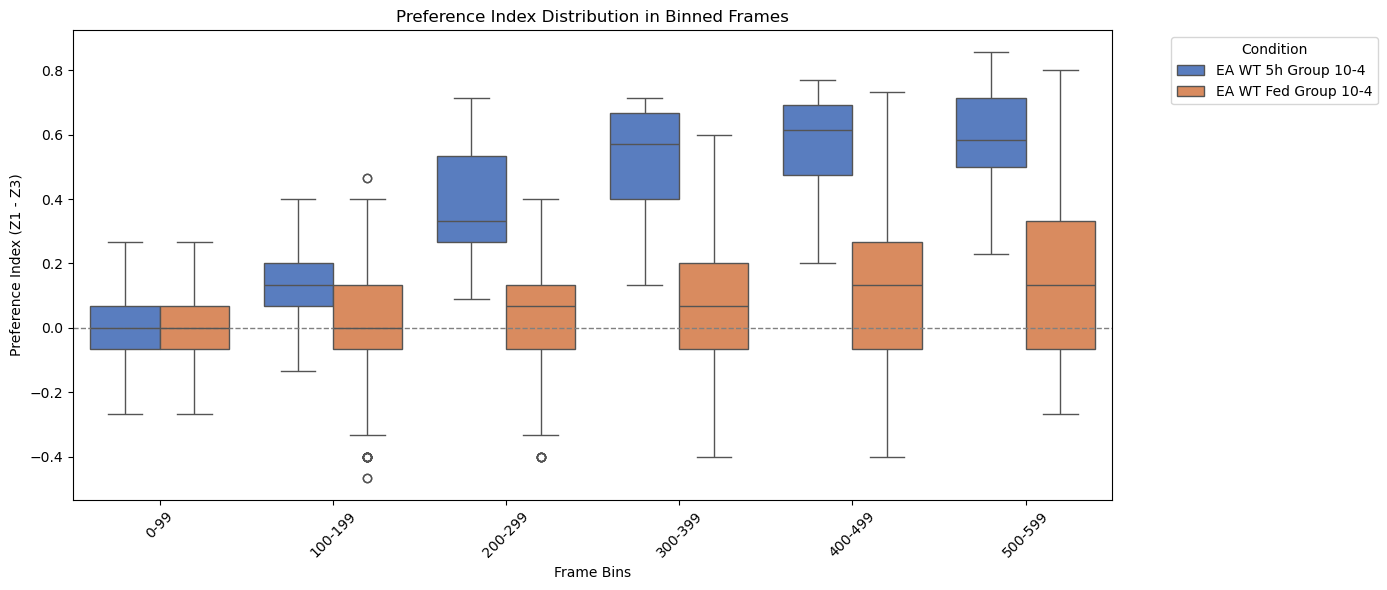

In [12]:
plotting.plot_preference_index_boxplots(df_EA_sub)

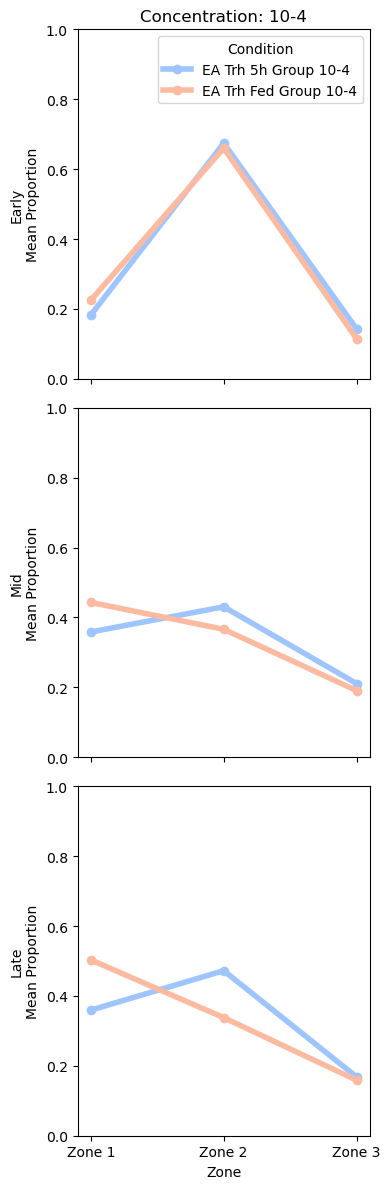

In [15]:
plotting.plot_zone_means_subplot(df_EA_sub)

              Condition  Frame  Proportion
0  EA Trh 5h Group 10-4   12.0         0.0
1  EA Trh 5h Group 10-4   13.0         0.0
2  EA Trh 5h Group 10-4   14.0         0.0
3  EA Trh 5h Group 10-4   15.0         0.0
4  EA Trh 5h Group 10-4   16.0         0.0
Index(['Condition', 'Frame', 'Proportion'], dtype='object')


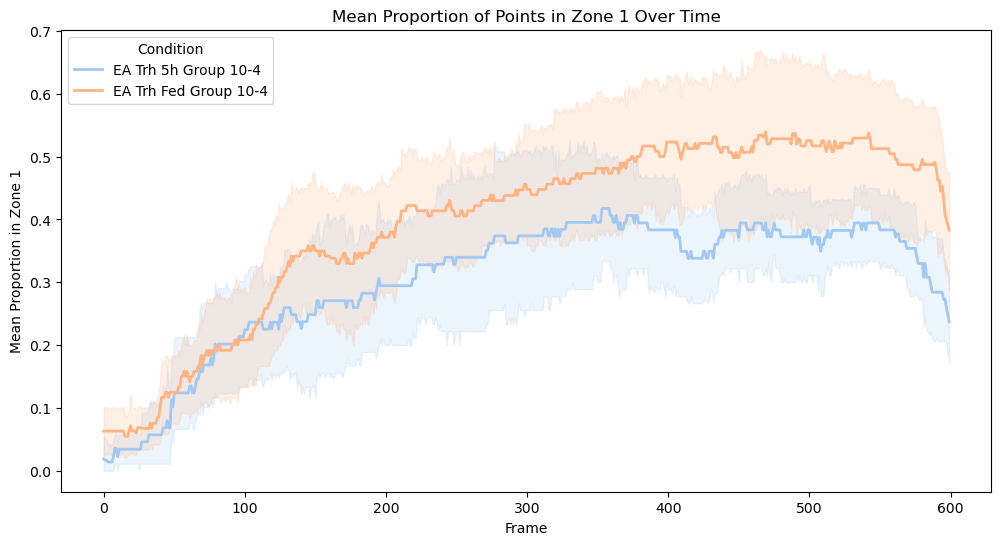

In [115]:
plotting.plot_zone_1_over_time(df_EA_sub) 

In [88]:
# plotting.plot_zone_means_subplot(df_PA_sub)

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:895: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.


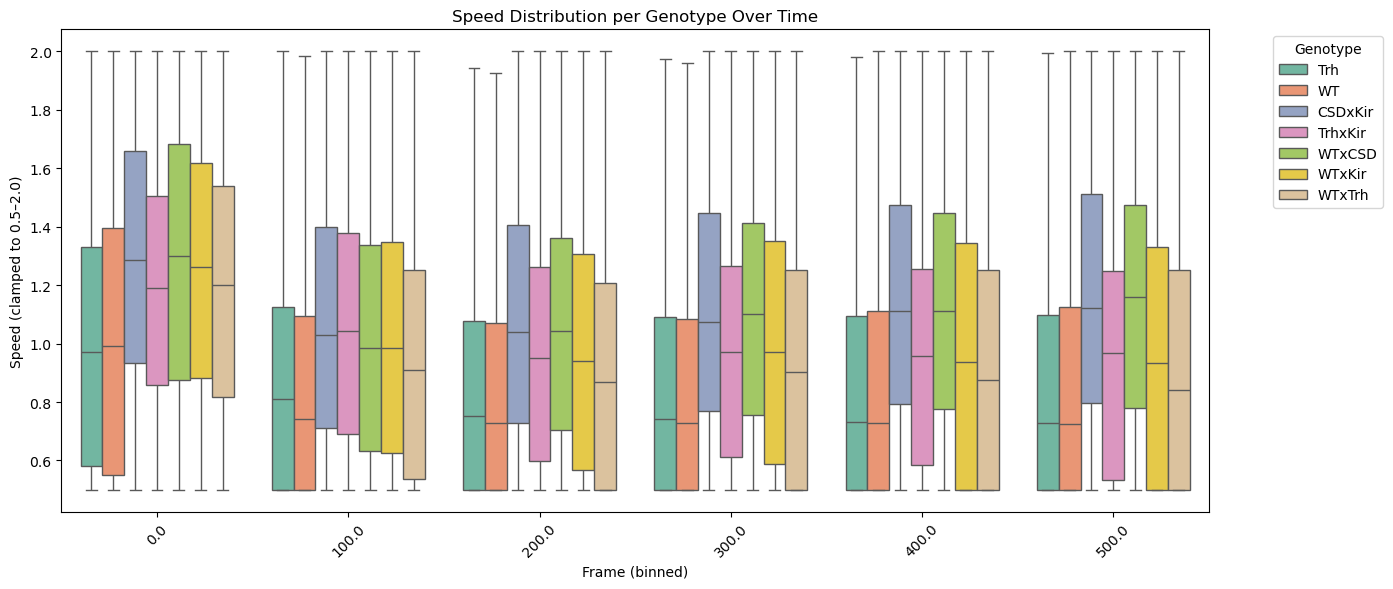

In [94]:
plotting.boxplot_speed_by_genotype(primary_df_interp)

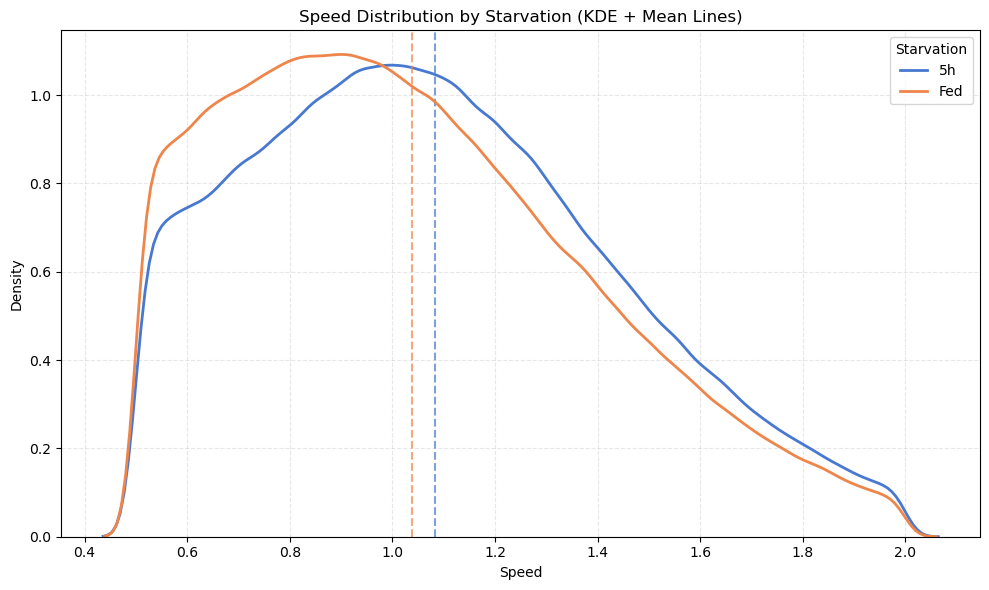

In [117]:
plotting.plot_speed_kde_by_starvation(primary_df_interp)

In [132]:
df_PA_sub = df_PA[(df_PA['Genotype'] == 'Trh') & (df_PA['Concentration'] == '10-4')]

In [129]:
# plotting.plot_zone_means_subplot(df_PA_sub)

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:1046: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.



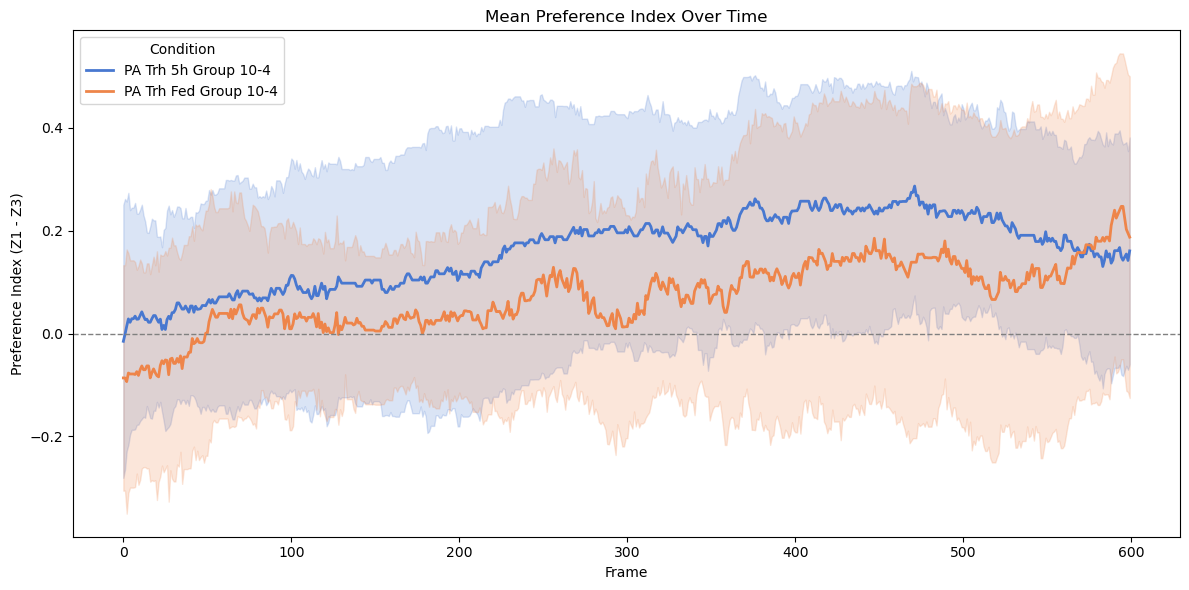

In [133]:
plotting.plot_preference_index_over_time(df_PA_sub) 

In [136]:
df_1P_sub = df_1P[(df_1P['Genotype'] == 'Trh') & (df_1P['Concentration'] == '10-2')]

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:1046: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.



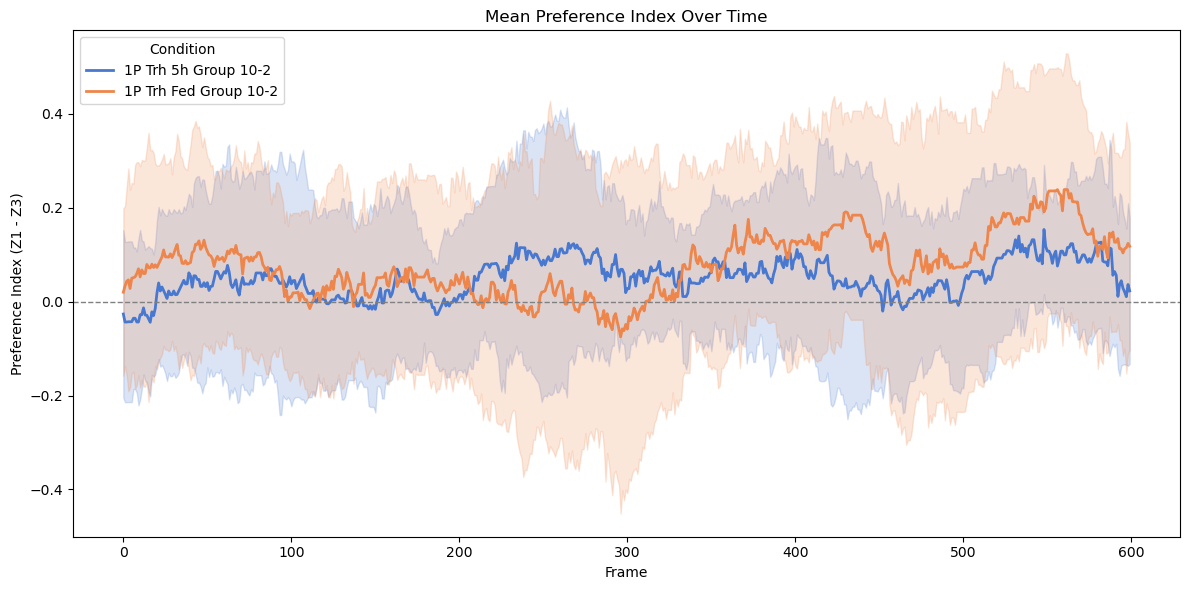

In [137]:
plotting.plot_preference_index_over_time(df_1P_sub) 